### Phase 4: Backtesting-Strategie
Wir plotten zunächst die Regime-Wahrscheinlichkeiten der Modelle sowie der tatsächlichen Modell-Signale.

Anschließend testen wir den Erfolg einer Investition in Abhängigkeit zum gewählten Modell und den unten beschriebenen Regeln.

*   **Regel:**
    *   Wenn Modell sagt "Bull": 100% Aktien (S&P 500).
    *   Wenn Modell sagt "Bear": 100% Bonds oder Cash.
*   **Transaktionskosten:** Integriere realistische Kosten (z.B. 0,1% pro Trade), da ML-Modelle oft zu nervös hin- und herschalten ("Churning").

In [15]:
import pandas as pd

# Daten aus dem data-Ordner laden
test_df = pd.read_parquet("../data/03_test_df_data.parquet")

Berechne Backtest für HMM mit 0.1% Kosten...
Berechne Backtest für MS_Univariate mit 0.1% Kosten...
Berechne Backtest für MS_Exo mit 0.1% Kosten...
Berechne Backtest für LSTM mit 0.1% Kosten...
Berechne Backtest für LSTM_Unsupervised mit 0.1% Kosten...


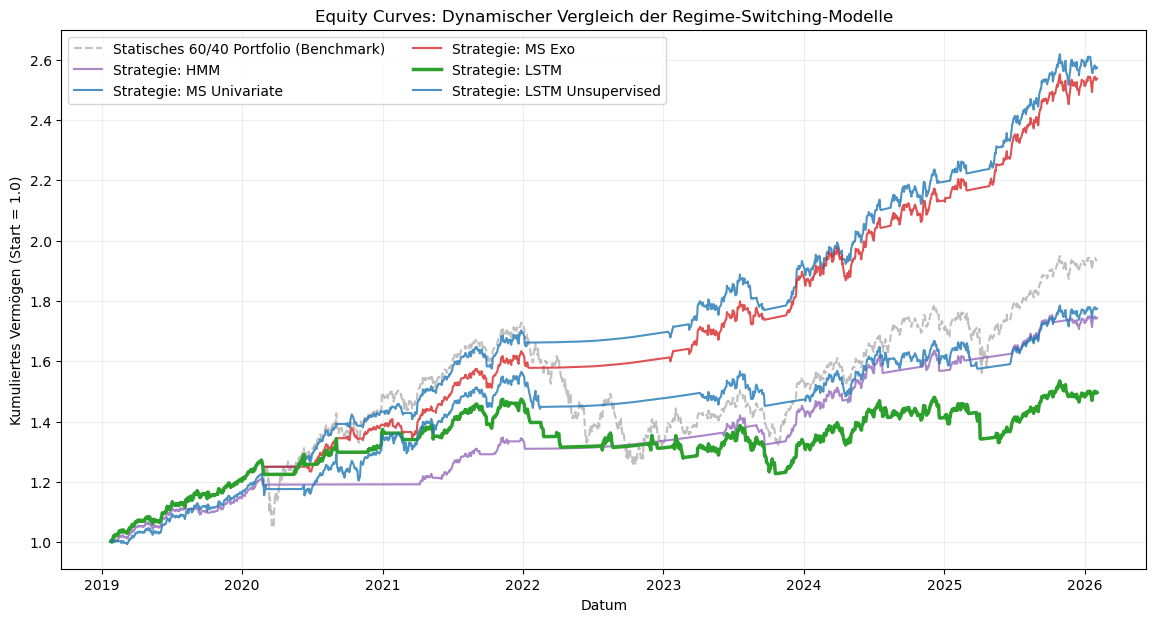

Backtesting abgeschlossen. 5 Strategien wurden berechnet.
backtesting_results Dataframe
            Buy_Hold       HMM  MS_Univariate    MS_Exo      LSTM  \
Date                                                                
2019-01-24  1.003217  1.003217       1.003217  1.003217  1.003217   
2019-01-25  1.006623  1.002306       1.006623  1.006623  1.006623   
2019-01-28  1.001197  1.002399       1.001197  1.001197  1.001197   
2019-01-29  1.002374  1.002493       1.002374  1.002374  1.002374   
2019-01-30  1.011386  1.002587       1.011386  1.011386  1.011386   
...              ...       ...            ...       ...       ...   
2026-01-27  1.943360  1.748791       2.581023  2.543840  1.500891   
2026-01-28  1.941319  1.746954       2.578312  2.541168  1.499314   
2026-01-29  1.939813  1.745599       2.576313  2.539197  1.498151   
2026-01-30  1.934708  1.741006       2.569533  2.532515  1.494209   
2026-02-02  1.938043  1.744006       2.573961  2.536880  1.496784   

            LS

In [16]:
# --- 5. Dynamisches Backtesting (Automatisierter Vergleich aller Modelle) ---

import matplotlib.pyplot as plt
import numpy as np

# Parameterdefinition
transaction_costs = 0.001  #(z.B. 0.002 für 0,2%)

def backtest(df, signal_col):
    """
    Berechnet die kumulierte Rendite einer Strategie.
    Bull (0): Investiert im 60/40 Portfolio
    Bear (1): Investiert im Geldmarkt (Cash_Returns)
    """
    # Signal um 1 Tag verschieben zur Vermeidung von Look-ahead Bias
    # Wir handeln heute basierend auf dem Signal, das gestern vorlag.
    trading_signal = df[signal_col].shift(1).fillna(0)
    
    # Logik: Wenn Signal 0 -> Portfolio-Return, sonst Cash-Return
    strategy_returns = np.where(trading_signal == 0, 
                                df['Returns'], 
                                df['Cash_Returns'])
    
    # Kumulierte Rendite berechnen (Startwert 1.0)
    return (1 + strategy_returns).cumprod()

def backtest(df, signal_col, fee=0.001): # 0.001 entspricht 0,1% pro Trade
    """
    Berechnet die kumulierte Rendite unter Berücksichtigung von Transaktionskosten.
    fee: Kosten für einen vollständigen Wechsel (z.B. 0.1% = 0.001)
    """
    # Signal um 1 Tag verschieben zur Vermeidung von Look-ahead Bias
    # Wir handeln heute basierend auf dem Signal, das gestern vorlag.
    trading_signal = df[signal_col].shift(1).fillna(0)
    
    # Trades identifizieren: Wo unterscheidet sich das Signal von heute zu gestern?
    # .diff().abs() liefert eine 1 an jedem Tag, an dem gewechselt wurde
    trades = trading_signal.diff().fillna(0).abs()
    
    # Logik: Wenn Signal 0 -> Portfolio-Return, sonst Cash-Return
    strategy_returns = np.where(trading_signal == 0, 
                                df['Returns'], 
                                df['Cash_Returns'])
    
    # Transaktionskosten abziehen
    # Wir ziehen die Gebühr nur an den Tagen ab, an denen ein Trade stattfindet
    net_strategy_returns = strategy_returns - (trades * fee)
    
    # Kumulierte Rendite berechnen
    return (1 + net_strategy_returns).cumprod()

# 1. Alle verfügbaren Modelle dynamisch identifizieren (anhand der _Signal Endung)
signal_cols = [col for col in test_df.columns if col.endswith('_Signal')]

# 2. Ergebnisse-DataFrame initialisieren
backtesting_results = pd.DataFrame(index=test_df.index)
# DataFrame für den zeitlichen Verlauf der Transaktionskosten
backtesting_transaction_costs = pd.DataFrame(index=test_df.index)

# Benchmark berechnen (Buy & Hold des 60/40 Portfolios)
backtesting_results['Buy_Hold'] = (1 + test_df['Returns']).cumprod()
# Buy & Hold hat 0 Transaktionskosten, da wir nie umschichten)
backtesting_transaction_costs['Buy_Hold'] = 0.0 # Keine Kosten

# Alle erkannten Modelle dynamisch backtesten
for sig_col in signal_cols:
    # Modellnamen extrahieren (alles vor dem letzten '_Signal')
    model_name = sig_col.rsplit('_', 1)[0]
    
    print(f"Berechne Backtest für {model_name} mit {transaction_costs*100}% Kosten...")
    backtesting_results[model_name] = backtest(test_df, sig_col, fee=transaction_costs)
    
    # Transaktionskosten im zeitlichen Verlauf berechnen
    # Wir nutzen die gleiche Logik wie in der Funktion (Shift + Diff)
    trading_signal = test_df[sig_col].shift(1).fillna(0)
    trades = trading_signal.diff().fillna(0).abs()
    backtesting_transaction_costs[model_name] = (trades * transaction_costs).cumsum()

# 3. Dynamische Visualisierung
plt.figure(figsize=(14, 7))

# Vordefinierte Farben für Konsistenz (optional)
color_map = {
    'Buy_Hold': 'gray',
    'MS_Univariate': 'tab:blue',
    'MS_Exo': 'tab:red',
    'HMM': 'tab:purple',
    'LSTM': 'tab:green'
}

# Plotte erst die Benchmark (Buy & Hold)
plt.plot(backtesting_results['Buy_Hold'], 
         label='Statisches 60/40 Portfolio (Benchmark)', 
         color=color_map.get('Buy_Hold', 'gray'), 
         alpha=0.5, linestyle='--')

# Plotte alle berechneten Strategien
for col in backtesting_results.columns:
    if col == 'Buy_Hold':
        continue
    
    # Stil-Anpassungen
    color = color_map.get(col, None) # Nimmt Standardfarbe falls Modell unbekannt
    linewidth = 2.5 if col == 'LSTM' else 1.5
    alpha = 1.0 if col == 'LSTM' else 0.8
    
    plt.plot(backtesting_results[col], 
             label=f'Strategie: {col.replace("_", " ")}', 
             color=color, linewidth=linewidth, alpha=alpha)

plt.title("Equity Curves: Dynamischer Vergleich der Regime-Switching-Modelle")
plt.xlabel("Datum")
plt.ylabel("Kumuliertes Vermögen (Start = 1.0)")
plt.legend(loc='upper left', ncol=2)
plt.grid(True, alpha=0.2)

# Equity Curve persistieren
plt.savefig('../assets/equity_curves.png', dpi=300, bbox_inches='tight')
plt.show()

# 4. Daten für das nächste Notebook (Evaluation) speichern
backtesting_results.to_parquet("../data/04_backtesting_results_data.parquet")

print(f"Backtesting abgeschlossen. {len(signal_cols)} Strategien wurden berechnet.")

print("backtesting_results Dataframe")
print(backtesting_results)
print("backtesting_transaction_costs Dataframe")
print(backtesting_transaction_costs)

#--- Wir erhalten in diesem Schritt neben df und test_df backtesting_results mit kumulierten Werten ----
#--- Außerdem erhalten wir das Dataframe backtesting_transaction_costs mit Verläufen der Transaktionskosten ---

In [17]:
# --- Performance & Drawdown Zusammenfassung ---

print("\n--- PERFORMANCE & DRAWDOWN ZUSAMMENFASSUNG ---")

summary_stats = []

for col in backtesting_results.columns:
    series = backtesting_results[col]
    
    # Finale Werte berechnen
    final_val = series.iloc[-1]
    total_ret = (final_val - 1) * 100
    
    # Max Drawdown berechnen
    roll_max = series.cummax()
    drawdown = series / roll_max - 1.0
    mdd = drawdown.min() * 100
    
    summary_stats.append({
        'Strategie': col,
        'Final Wealth': f"{final_val:.4f}",
        'Total Return': f"{total_ret:+.2f}%",
        'Max Drawdown': f"{mdd:.2f}%"
    })

# In DataFrame umwandeln
performance_summary_df = pd.DataFrame(summary_stats).set_index('Strategie')

# Als Markdown persistieren
performance_summary_df.to_markdown('../assets/performance_summary.md')

print("Zusammenfassung erfolgreich unter ../assets/performance_summary.md gespeichert.")

# Im Notebook anzeigen
display(performance_summary_df)


--- PERFORMANCE & DRAWDOWN ZUSAMMENFASSUNG ---
Zusammenfassung erfolgreich unter ../assets/performance_summary.md gespeichert.


,Final Wealth,Total Return,Max Drawdown
Strategie,,,
Buy_Hold,1.9380,+93.80%,-27.10%
HMM,1.7440,+74.40%,-6.79%
MS_Univariate,2.5740,+157.40%,-6.25%
MS_Exo,2.5369,+153.69%,-5.44%
LSTM,1.4968,+49.68%,-16.77%
LSTM_Unsupervised,1.7748,+77.48%,-7.85%


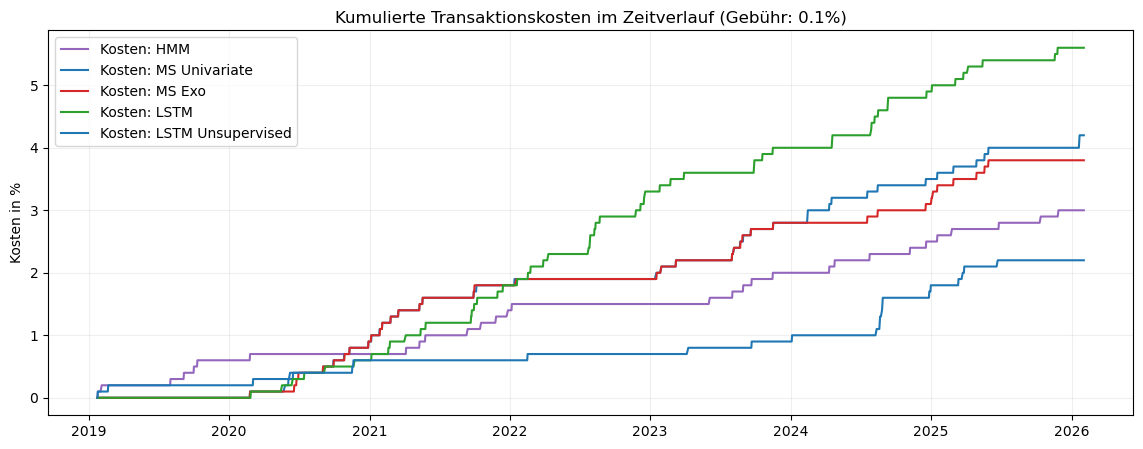

In [18]:
# Visualisierung der kumulierten Transaktionskosten
plt.figure(figsize=(14, 5))
for col in backtesting_transaction_costs.columns:
    if col == 'Buy_Hold': continue
    color = color_map.get(col, None)
    plt.plot(backtesting_transaction_costs[col] * 100, label=f'Kosten: {col.replace("_", " ")}', color=color)

plt.title(f"Kumulierte Transaktionskosten im Zeitverlauf (Gebühr: {transaction_costs*100}%)")
plt.ylabel("Kosten in %")
plt.legend(loc='upper left')
plt.grid(True, alpha=0.2)
plt.savefig('../assets/transaction_costs.png', dpi=300, bbox_inches='tight')
plt.show()

Running Scenario: Standard...


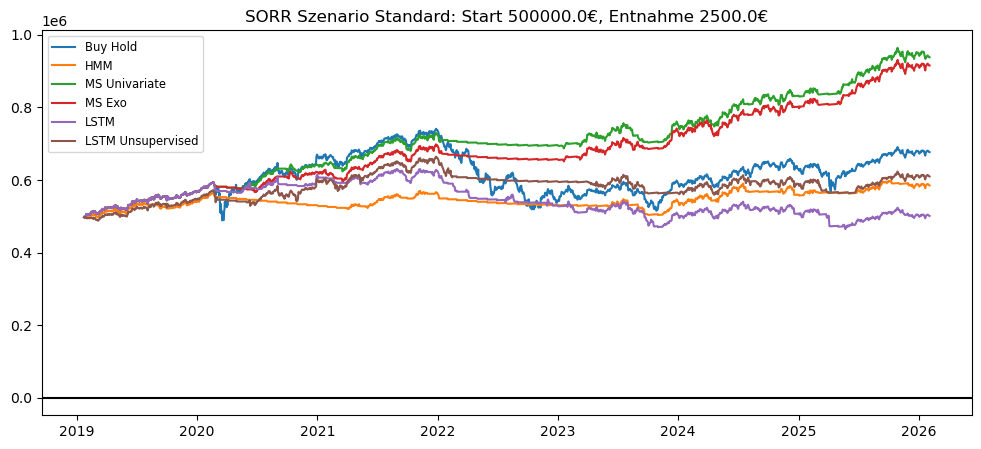

Running Scenario: Aggressive...


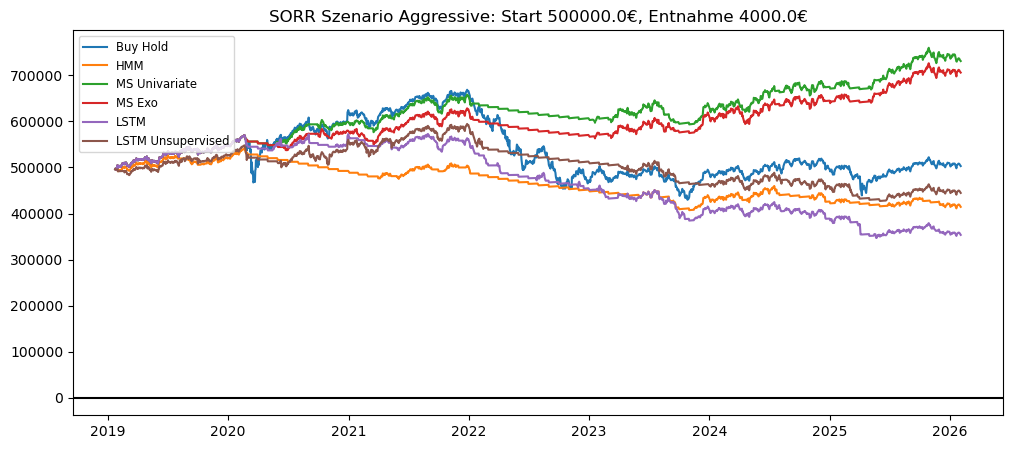

Running Scenario: Low_Capital...


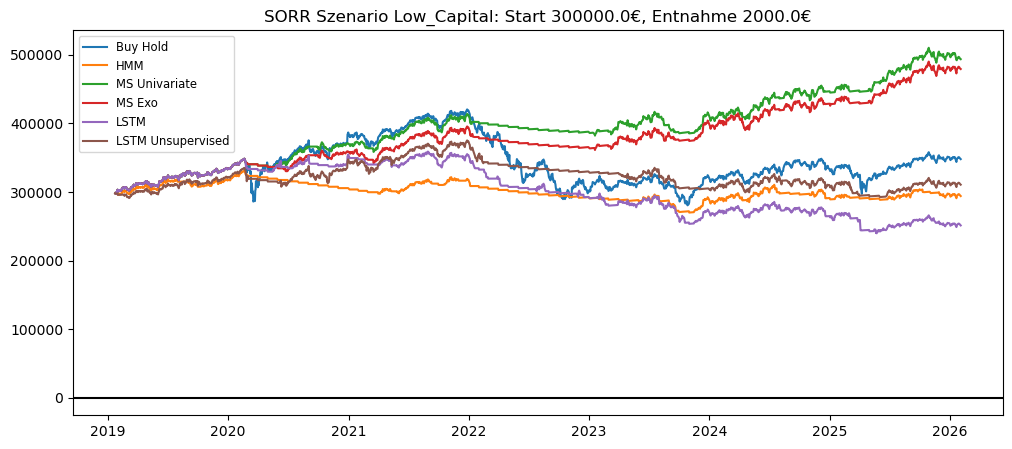

Alle Szenarien berechnet und unter ../assets/ gespeichert.


Endkapital         Status
Szenario    Strategie                                     
Standard    Buy Hold           676,642.08 €  Kapitalerhalt
            HMM                585,004.69 €  Kapitalerhalt
            MS Univariate      937,966.15 €  Kapitalerhalt
            MS Exo             915,383.59 €  Kapitalerhalt
            LSTM               500,764.28 €  Kapitalerhalt
            LSTM Unsupervised  609,661.30 €  Kapitalerhalt
Aggressive  Buy Hold           503,078.66 €  Kapitalerhalt
            HMM                414,483.10 €  Kapitalerhalt
            MS Univariate      731,033.21 €  Kapitalerhalt
            MS Exo             705,989.87 €  Kapitalerhalt
            LSTM               353,627.28 €  Kapitalerhalt
            LSTM Unsupervised  444,716.86 €  Kapitalerhalt
Low_Capital Buy Hold           347,899.59 €  Kapitalerhalt
            HMM                294,065.88 €  Kapitalerhalt
            MS Univariate      493,620.95 €  Kapitalerhalt
            MS Exo             479,244.75 €  Kapitalerhalt
            LSTM               251,267.07 €  Kapitalerhalt
            LSTM Unsupervised  310,662.00 €  Kapitalerhalt

            Standard_Buy_Hold   Standard_HMM  Standard_MS_Univariate  \
Date                                                                   
2019-01-24      497497.500000  497500.000000           497497.500000   
2019-01-25      499186.695104  497048.459525           499186.695104   
2019-01-28      496496.054432  497094.475955           496496.054432   
2019-01-29      497079.824307  497141.127877           497079.824307   
2019-01-30      501548.548273  497187.784178           501548.548273   
...                       ...            ...                     ...   
2026-01-27      681007.814726  589119.023062           943048.834684   
2026-01-28      680292.569066  588500.285927           942058.373824   
2026-01-29      679764.948596  588043.857602           941327.733354   
2026-01-30      677976.141960  586496.415715           938850.622259   
2026-02-02      676642.075607  585004.691911           937966.150665   

            Standard_MS_Exo  Standard_LSTM  Standard_LSTM_Unsup

In [19]:
#--- SORR Simulation: Analyse der Entnahmephase ---

def run_sorr_simulation(backtest_res, test_data, start_capital, monthly_withdrawal, fee_rate):
    """
    Führt eine SORR-Simulation für alle im DataFrame enthaltenen Strategien durch.
    """
    daily_ret = backtest_res.pct_change().fillna(0)
    path_results = pd.DataFrame(index=daily_ret.index)
    
    for col in daily_ret.columns:
        capital_path = []
        current_capital = start_capital
        last_month = -1
        
        # Signalzuordnung für Gebührenlogik
        sig_col = None
        if col == 'Buy_Hold': sig_col = None
        elif f"{col}_Signal" in test_data.columns: sig_col = f"{col}_Signal"
        elif col == 'HMM_Based' and 'HMM_Regime' in test_data.columns: sig_col = 'HMM_Regime'

        for date, ret in daily_ret[col].items():
            current_capital *= (1 + ret)
            
            if date.month != last_month:
                withdrawal = monthly_withdrawal
                is_invested = True
                if sig_col is not None and date in test_data.index:
                    if test_data.at[date, sig_col] == 1:
                        is_invested = False
                
                if is_invested:
                    withdrawal += (monthly_withdrawal * fee_rate)
                
                current_capital -= withdrawal
                last_month = date.month
            
            current_capital = max(0, current_capital)
            capital_path.append(current_capital)
            
        path_results[col] = capital_path
    return path_results

# Definition der Szenarien
scenarios = {
    "Standard": {"start": 500000.0, "withdrawal": 2500.0, "fee": 0.001},
    "Aggressive": {"start": 500000.0, "withdrawal": 4000.0, "fee": 0.001},
    "Low_Capital": {"start": 300000.0, "withdrawal": 2000.0, "fee": 0.002}
}

sorr_summaries = []

# Initialisierung eines leeren DataFrames für alle Simulationspfade
backtesting_sorr_simulation = pd.DataFrame(index=backtesting_results.index)

for name, params in scenarios.items():
    print(f"Running Scenario: {name}...")
    
    # Simulation berechnen
    sim_results = run_sorr_simulation(
        backtesting_results, 
        test_df, 
        params["start"], 
        params["withdrawal"], 
        params["fee"]
    )
    
    # Alle Ergebnisse dem zentralen DataFrame hinzufügen
    # Wir erstellen Spaltennamen in der Form "Szenario_Strategie" 
    for col in sim_results.columns:
        column_name = f"{name}_{col}"
        backtesting_sorr_simulation[column_name] = sim_results[col]
    
    # Visualisierung pro Szenario
    plt.figure(figsize=(12, 5))
    for col in sim_results.columns:
        plt.plot(sim_results[col], label=col.replace('_', ' '))
    
    plt.title(f"SORR Szenario {name}: Start {params['start']}€, Entnahme {params['withdrawal']}€")
    plt.axhline(y=0, color='black', linestyle='-')
    plt.legend(loc='upper left', fontsize='small')
    plt.savefig(f'../assets/sorr_sim_{name.lower()}.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Statistische Auswertung für dieses Szenario sammeln
    for col in sim_results.columns:
        final_cap = sim_results[col].iloc[-1]
        status = "Kapitalerhalt" if final_cap > 0 else f"Erschöpft ({sim_results[sim_results[col] <= 0].index[0].strftime('%Y')})"
        sorr_summaries.append({
            "Szenario": name,
            "Strategie": col.replace('_', ' '),
            "Endkapital": f"{final_cap:,.2f} €",
            "Status": status
        })

# 2.) Zusammenfassende Tabelle aller Szenarien erstellen und persistieren
sorr_multi_eval = pd.DataFrame(sorr_summaries).set_index(['Szenario', 'Strategie'])
sorr_multi_eval.to_markdown('../assets/sorr_summary.md', index=True)

print("Alle Szenarien berechnet und unter ../assets/ gespeichert.")
display(sorr_multi_eval)

print(backtesting_sorr_simulation)

#--- Wir erhalten in diesem Schritt neben df, test_df, backtesting_results, backtesting_transaction_costs nun backtesting_sorr_simulation ----

In [20]:
output_path = "../data/04_backtesting_results_data.parquet"

# Speichern als Parquet
backtesting_results.to_parquet(output_path)

print(f"Dataframe erfolgreich unter {output_path} gespeichert.")

Dataframe erfolgreich unter ../data/04_backtesting_results_data.parquet gespeichert.


In [21]:
output_path = "../data/04_backtesting_transaction_costs_data.parquet"

# Speichern als Parquet
backtesting_transaction_costs.to_parquet(output_path)

print(f"Transaktionskosten-Dataframe erfolgreich unter {output_path} gespeichert.")

Transaktionskosten-Dataframe erfolgreich unter ../data/04_backtesting_transaction_costs_data.parquet gespeichert.


In [22]:
output_path = "../data/04_backtesting_sorr_simulation.parquet"

# Speichern als Parquet
backtesting_sorr_simulation.to_parquet(output_path)

print(f"SORR-Simulations-Dataframe erfolgreich unter {output_path} gespeichert.")

SORR-Simulations-Dataframe erfolgreich unter ../data/04_backtesting_sorr_simulation.parquet gespeichert.
